In [156]:
import numpy as np
import dpluspy

In [157]:
import matplotlib.pyplot as plt

In [158]:
bmap_file = "data/B_maps/CADD_bestfit/chr20.bmap.txt"
mask_file = "../../data/bed_files/filterbed_intergenic/mask_chr20.bed.gz"

In [159]:
B_arr = np.loadtxt(bmap_file)
bvals = B_arr[:, 0] * 1e-3
segments = B_arr[:, 1].astype(np.int64)
positions = np.cumsum(segments)
print(bvals)
print(segments)

[0.651 0.65  0.649 ... 0.538 0.537 0.536]
[226151 111964  23099 ...   1176    817 832953]


In [160]:
mask_regions, _ = dpluspy.utils._read_bed_file(mask_file)
mask = dpluspy.utils._regions_to_mask(mask_regions, length=positions[-1])
inverse_mask = ~mask

In [161]:
B_map = np.zeros(int(positions[-1]))
end_points = np.concatenate([[0], positions]).astype(np.int64)
for ii in range(len(end_points)):
    if ii == 0:
        continue
    start = end_points[ii - 1]
    end = end_points[ii]
    B_map[start:end] = bvals[ii - 1]

In [162]:
mask_B_map = B_map[inverse_mask]
print(mask_B_map)

[0.651 0.651 0.651 ... 0.536 0.536 0.536]


In [163]:
# Proof of concept for quartile estimation via binning
quarts = [0.25, 0.50, 0.75]
print(np.quantile(mask_B_map, quarts))
bins = np.linspace(0, 1, 1001)
histogram, _ = np.histogram(mask_B_map, bins=bins)
print(histogram[-30:])
quartiles = np.quantile(
    bins[:-1], quarts, weights=histogram, method="inverted_cdf")
print(quartiles)

[0.773 0.886 0.939]
[132042 118948 133860 121694 134330 146203 129179 120337  80083 110919
  89177  92730  94763  97185  61405  76795  39912  51737  44970  37477
  40897  24883  28248  22999  20020   5951      0      0      0      0]
[0.773 0.886 0.939]


In [167]:
print(len(np.where(mask_B_map <= 0.773)[0]) / len(mask_B_map))
print(len(np.where(mask_B_map < 0.773)[0]) / len(mask_B_map))
print(len(np.where(mask_B_map < 0.886)[0]) / len(mask_B_map))
print(len(np.where((mask_B_map >= 0.773) & (mask_B_map < 0.886))[0]) / len(mask_B_map))

0.2507251651827391
0.24970100595850428
0.49992830425719476
0.2502272982986905


(0.0, 1159075.5)

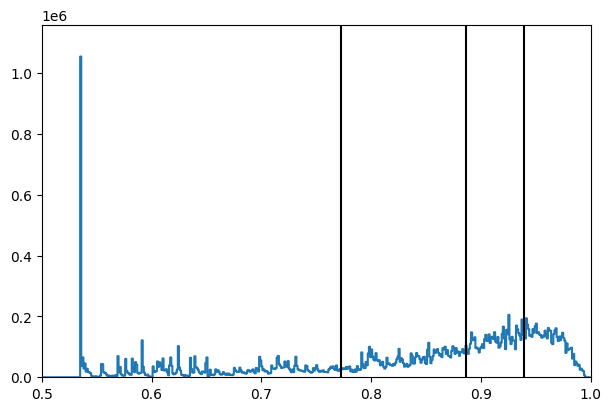

In [168]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.step(bins[:-1], histogram)
ax.vlines(quartiles, 0, np.max(histogram) * 1.1, color="black")
ax.set_xlim(0.5, 1)
ax.set_ylim(0, np.max(histogram) * 1.1)

In [169]:
# Functions for evaluating quartiles
def get_B_map(bmap_file):
    B_arr = np.loadtxt(bmap_file)
    bvals = B_arr[:, 0] * 1e-3
    segments = B_arr[:, 1].astype(np.int64)
    positions = np.cumsum(segments)
    B_map = np.zeros(int(positions[-1]))
    end_points = np.concatenate([[0], positions]).astype(np.int64)
    for ii in range(len(end_points)):
        if ii == 0:
            continue
        start = end_points[ii - 1]
        end = end_points[ii]
        B_map[start:end] = bvals[ii - 1]
    return B_map

In [170]:
get_B_map(bmap_file)

array([0.651, 0.651, 0.651, ..., 0.536, 0.536, 0.536], shape=(63025520,))

In [171]:
# Establish genome-wide quartiles!
histogram = 0
for ii in range(1, 23):
    bmap_file = f"data/B_maps/CADD_bestfit/chr{ii}.bmap.txt"
    mask_file = f"../../data/bed_files/filterbed_intergenic/mask_chr{ii}.bed.gz"
    B_map = get_B_map(bmap_file)
    mask_regions, _ = dpluspy.utils._read_bed_file(mask_file)
    mask = dpluspy.utils._regions_to_mask(mask_regions, length=len(B_map))
    mask_B_map = B_map[~mask]
    hist_ii, _ = np.histogram(mask_B_map, bins=bins)
    histogram += hist_ii
    print(ii, np.sum(hist_ii))

total_quartiles = np.quantile(
    bins[:-1], quarts, weights=histogram, method="inverted_cdf")

1 94129747
2 105815689
3 87771347
4 83063387
5 78698143
6 74131893
7 63513566
8 63788302
9 47750878
10 55767210
11 55560102
12 55751703
13 43784850
14 37966849
15 33100346
16 29742880
17 28421836
18 34777863
19 15040945
20 26103363
21 14477248
22 12392408


In [172]:
print(np.sum(histogram))
print(histogram[536] / np.sum(histogram))
print(total_quartiles)

1141550555
0.03723989867448314
[0.736 0.843 0.91 ]


(0.0, 46762349.7)

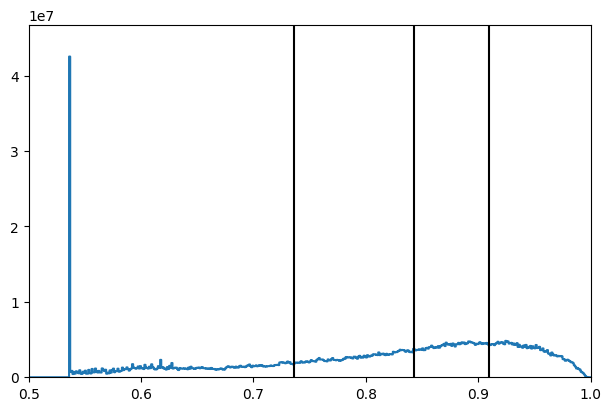

In [173]:
fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.step(bins[1:], histogram)
ax.vlines(total_quartiles, 0, np.max(histogram) * 1.1, color="black")
ax.set_xlim(0.5, 1)
ax.set_ylim(0, np.max(histogram) * 1.1)

In [174]:
quartile_edges = np.concatenate(([0], total_quartiles, [1]))
quartile_edges[0] = 0
quartile_edges[-1] = 1
print(quartile_edges)

for ii in range(4):
    sites = ~((B_map >= quartile_edges[ii]) & (B_map < quartile_edges[ii + 1]))
    b_regions = dpluspy.utils._mask_to_regions(sites)
    regions = dpluspy.utils._intersect_regions([mask_regions, b_regions])
    print(np.sum(np.diff(regions, axis=1)))

[0.    0.736 0.843 0.91  1.   ]
3056723
1349143
1900222
6086320


In [177]:
# Write masks
sums = [0, 0, 0, 0]
for ii in range(1, 23):
    bmap_file = f"data/B_maps/CADD_bestfit/chr{ii}.bmap.txt"
    mask_file = f"../../data/bed_files/filterbed_intergenic/mask_chr{ii}.bed.gz"
    B_map = get_B_map(bmap_file)
    mask_regions, _ = dpluspy.utils._read_bed_file(mask_file)
    for jj in range(4):
        lower_lim = quartile_edges[jj]
        upper_lim = quartile_edges[jj + 1]
        sites = ~((B_map >= lower_lim) & (B_map < upper_lim))
        b_regions = dpluspy.utils._mask_to_regions(sites)
        regions = dpluspy.utils._intersect_regions([mask_regions, b_regions])
        out_fname = f"data/bed_files/quartile_{jj}/mask_chr{ii}.bed.gz"
        dpluspy.utils._write_bed_file(out_fname, regions, f"chr{ii}")
        num_sites = np.sum(np.diff(regions, axis=1))
        sums[jj] += num_sites
        print((ii, jj), num_sites)

(1, 0) 27700738
(1, 1) 24792429
(1, 2) 23111211
(1, 3) 18525369
(2, 0) 32359599
(2, 1) 29056614
(2, 2) 23995328
(2, 3) 20404148
(3, 0) 25484943
(3, 1) 24017189
(3, 2) 22410244
(3, 3) 15858971
(4, 0) 12489898
(4, 1) 21110757
(4, 2) 26846841
(4, 3) 22615891
(5, 0) 21024455
(5, 1) 22066856
(5, 2) 19307307
(5, 3) 16299525
(6, 0) 19402437
(6, 1) 22829074
(6, 2) 17587788
(6, 3) 14312594
(7, 0) 15027802
(7, 1) 15078643
(7, 2) 17554145
(7, 3) 15852976
(8, 0) 14439230
(8, 1) 15790537
(8, 2) 15641266
(8, 3) 17917269
(9, 0) 11675639
(9, 1) 11615365
(9, 2) 13571082
(9, 3) 10888792
(10, 0) 15525388
(10, 1) 11510745
(10, 2) 12887207
(10, 3) 15843870
(11, 0) 14215275
(11, 1) 12861271
(11, 2) 16016091
(11, 3) 12467465
(12, 0) 14059268
(12, 1) 15662314
(12, 2) 13202117
(12, 3) 12828004
(13, 0) 7511800
(13, 1) 10922982
(13, 2) 11797955
(13, 3) 13552113
(14, 0) 9437150
(14, 1) 11316438
(14, 2) 10417569
(14, 3) 6795692
(15, 0) 9176122
(15, 1) 6745449
(15, 2) 6316027
(15, 3) 10862748
(16, 0) 6265731
(16, 1

In [179]:
print(np.array(sums) / np.sum(sums))

[0.24900219 0.25060817 0.24821354 0.2521761 ]
